# Lead-lag discovery: cross-correlations on irregular ticks

Who moves first? Lead-lag analysis pairs related instruments: index against
futures, ADR against home listing, correlated FX crosses. It is plagued by one
mechanical problem. Ticks arrive irregularly and *asynchronously*, and every
naive fix biases the answer. Bucketing and last-observation-carried-forward
both do it, and the result is the Epps effect.

We work through the toolkit on a pair with a *known, injected* lead:

1. build a synthetic GBPUSD that follows EURUSD with a 500 ms lag,
2. bucket and correlate: the classic CCF on a 250 ms grid via `time_bucket`,
3. align at tick level with `asof_join` and sweep the staleness tolerance,
4. run the Hayashi-Yoshida estimator, which needs no grid at all and, swept
   over time shifts, localizes the lag without ever resampling,
5. finish with a real-data reality check on a daily equity pair.

In [1]:
import numpy as np
import pandas as pd
import pyarrow as pa

import h5i_db
from h5i_db import col, sql_expr
import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("alpha_leadlag"), create=True)

## 1. The data

`cu.make_fx_ticks` gives 24/7 FX-style ticks, one row per quote update.

| column | type | meaning |
| --- | --- | --- |
| `ts` | `timestamp[us, tz=UTC]` | quote timestamp, ascending |
| `pair` | `string` | currency pair |
| `bid`, `ask` | `float64` | best bid and offer |

We take 24 hours of EURUSD at 20,000 ticks per hour, roughly one every 180 ms.

In [2]:
LAG_US = 500_000
BETA = 0.9

eur = cu.make_fx_ticks(pairs=["EURUSD"], hours=24, ticks_per_hour=20_000).to_pandas()
print(f"{len(eur):,} EURUSD ticks x {eur.shape[1]} columns")
eur.head()

480,000 EURUSD ticks x 4 columns


,ts,pair,bid,ask
0,2026-06-01 00:00:00.191127+00:00,EURUSD,1.07998,1.08006
1,2026-06-01 00:00:00.202457+00:00,EURUSD,1.08012,1.08018
2,2026-06-01 00:00:00.546002+00:00,EURUSD,1.08005,1.08009
3,2026-06-01 00:00:00.740766+00:00,EURUSD,1.08001,1.08009
4,2026-06-01 00:00:00.775930+00:00,EURUSD,1.07999,1.08007


The generator produces *independent* pairs, so any lead-lag we found between
two of them would be noise. Instead we treat its EURUSD as the leader and
construct GBPUSD ourselves.

At each GBPUSD tick time `t`, the log-mid is
`beta * eur_logmid(t - 500ms) + idio(t)`. That is a backward-asof sample of
the leader's path, half a second stale, plus an idiosyncratic random walk of
comparable magnitude.

Ground truth: EURUSD leads by exactly 500 ms with beta 0.9, and nothing else
connects the two.

In [3]:
eur_ts = eur["ts"].astype("int64").to_numpy()
eur_logmid = np.log((eur["bid"] + eur["ask"]) / 2).to_numpy()

rng = np.random.default_rng(99)
n = len(eur)
t0, t1 = eur_ts[0], eur_ts[-1]
gbp_ts = np.sort(rng.integers(t0 + LAG_US, t1, n))  # own asynchronous clock

# backward-asof sample of the leader at (t - 500ms), in numpy
idx = np.searchsorted(eur_ts, gbp_ts - LAG_US, side="right") - 1
idio = np.cumsum(rng.normal(0, 4e-5, n))
gbp_logmid = np.log(1.27) + BETA * (eur_logmid[idx] - eur_logmid[0]) + idio
gbp_mid = np.exp(gbp_logmid)
half = gbp_mid * rng.uniform(0.2e-4, 1e-4, n) / 2

gbp = pd.DataFrame(
    {
        "ts": pd.to_datetime(gbp_ts, unit="us", utc=True).astype("datetime64[us, UTC]"),
        "pair": "GBPUSD",
        "bid": np.round(gbp_mid - half, 5),
        "ask": np.round(gbp_mid + half, 5),
    }
)
fx = (
    pd.concat([eur, gbp])
    .sort_values(["ts", "pair"])
    .reset_index(drop=True)
)
schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("pair", pa.string()),
        pa.field("bid", pa.float64()),
        pa.field("ask", pa.float64()),
    ]
)
db.create_table("fx", schema, time_column="ts", sort_key=["ts", "pair"])
db.append("fx", pa.Table.from_pandas(fx, preserve_index=False).cast(schema), note="EURUSD + lagged GBPUSD")
print(f"{len(fx):,} ticks over 24h ({n:,} per pair, ~{n / 86_400:.1f}/sec)")

960,000 ticks over 24h (480,000 per pair, ~5.6/sec)


## 2. The bucketed CCF: `time_bucket` at 250 ms

The classic approach resamples both series to a fine common grid, computes
returns, and correlates at every lead/lag offset.

`time_bucket` takes sub-second widths such as `'250ms'`, so the grid reduction
happens in the database. One GROUP BY turns 960k ticks into per-bucket closing
mids, streaming on sorted storage. The pandas side just forward-fills the grid
and shifts.

In [4]:
# The builder's time_bucket() parses whole-second units only, so the 250 ms
# width comes in through the escape hatch - everything else is still verbs.
BUCKET_250MS = sql_expr("time_bucket('250ms', ts)")

bucketed = (
    db.table("fx")
    .group_by(BUCKET_250MS.alias("bucket"), "pair")
    .agg(mid=((col("bid") + col("ask")) / 2).last("ts"))
    .to_pandas()
)

grid = bucketed.pivot(index="bucket", columns="pair", values="mid")
full_index = pd.date_range(grid.index.min(), grid.index.max(), freq="250ms", tz="UTC")
rets = np.log(grid.reindex(full_index).ffill()).diff().dropna()

lags = np.arange(-12, 13)
ccf = pd.Series(
    {k: rets["EURUSD"].corr(rets["GBPUSD"].shift(-k)) for k in lags}
)
band = 1.96 / np.sqrt(len(rets))

CCF peak at k = +0.50s (corr 0.34); corr at k=0: -0.00


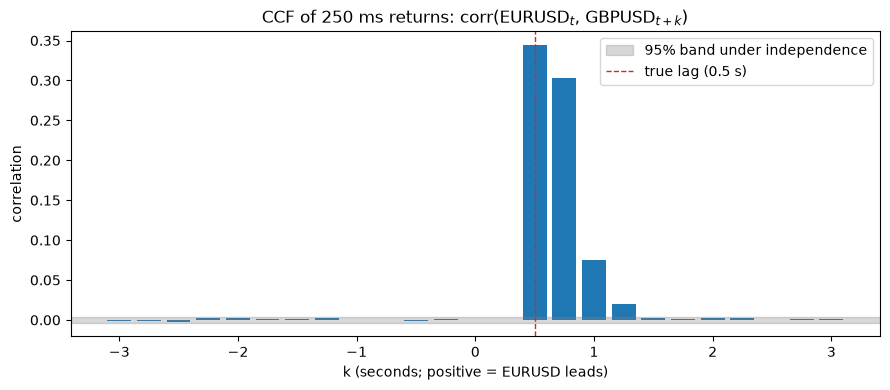

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(lags * 0.25, ccf.values, width=0.2, color="tab:blue")
ax.axhspan(-band, band, color="gray", alpha=0.3, label="95% band under independence")
ax.axvline(0.5, color="tab:red", ls="--", lw=1, label="true lag (0.5 s)")
ax.set_title("CCF of 250 ms returns: corr(EURUSD$_t$, GBPUSD$_{t+k}$)")
ax.set_xlabel("k (seconds; positive = EURUSD leads)")
ax.set_ylabel("correlation")
ax.legend()
fig.tight_layout()
peak = ccf.idxmax()
print(f"CCF peak at k = {peak * 0.25:+.2f}s (corr {ccf.max():.2f}); corr at k=0: {ccf.loc[0]:.2f}")

The CCF nails the direction and localizes the lag. The mass sits at +0.5 s and
+0.75 s: the injected 500 ms, plus the staleness of last-tick sampling, which
smears the effect one bucket to the right. Ticks arrive every 180 ms or so, so
a bucket's "closing mid" is itself slightly stale.

There is nothing at zero and nothing at negative lags, so GBPUSD never leads.

This is the discretization tradeoff in miniature. A coarser grid would pile
the whole effect into one bar at lag zero and *hide* the direction. A finer
grid thins each bucket until carried-forward zeros dominate, which is the Epps
effect.

## 3. Tick-level alignment: `asof_join` and the staleness tolerance

Before estimating anything grid-free, the workhorse operation is aligning one
irregular series to another: for each GBPUSD tick, the latest EURUSD tick.
That is `asof_join(..., 'backward', tolerance)`.

The tolerance, in raw microseconds, is a data-quality dial. How stale a leader
quote are you willing to accept? We audit a 20-minute window, sweeping the
tolerance and tracking both the match rate and the correlation of aligned
tick-to-tick returns.

Windowed extracts keep the audit fast and the numbers inspectable. We assert
the join returned one row per left tick and cross-check a sample against
`pandas.merge_asof`, which is standard hygiene for any ASOF pipeline.

In [6]:
w0 = int(pd.Timestamp("2026-06-01 12:00", tz="UTC").value // 1000)
w1 = int(pd.Timestamp("2026-06-01 12:20", tz="UTC").value // 1000)
BUF_US = 10_000_000  # give the window a 10s run-up so early ticks can match

qa_schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("base", pa.string()),
        pa.field("bid", pa.float64()),
        pa.field("ask", pa.float64()),
    ]
)
eur_w = eur[(eur["ts"].astype("int64") >= w0 - BUF_US) & (eur["ts"].astype("int64") < w1)]
gbp_w = gbp[(gbp["ts"].astype("int64") >= w0) & (gbp["ts"].astype("int64") < w1)]
for name, frame in (("eur_qa", eur_w), ("gbp_qa", gbp_w)):
    tbl = pa.Table.from_pandas(
        frame.assign(base="USD")[["ts", "base", "bid", "ask"]], preserve_index=False
    ).cast(qa_schema)
    db.create_table(name, qa_schema, time_column="ts")
    db.append(name, tbl, note="QA window 12:00-12:20")
print(f"QA window: {len(gbp_w):,} follower ticks, {len(eur_w):,} leader ticks")

rows = []
for tol_ms in (50, 100, 250, 500, 1000, 5000):
    j = (
        db.table("gbp_qa")
        .join_asof(db.table("eur_qa"), on="ts", by="base", tolerance=tol_ms * 1000)
        .select(
            "ts", "ts_right",
            gbp_mid=(col("bid") + col("ask")) / 2,
            eur_mid=(col("bid_right") + col("ask_right")) / 2,
        )
        .sort("ts")
        .to_pandas()
    )
    assert len(j) == len(gbp_w), "asof_join must return one row per left tick"
    matched = j.dropna(subset=["eur_mid"])
    r = np.log(matched[["gbp_mid", "eur_mid"]]).diff().dropna()
    rows.append(
        {
            "tolerance_ms": tol_ms,
            "match_rate": len(matched) / len(j),
            "aligned_ret_corr": r["gbp_mid"].corr(r["eur_mid"]),
        }
    )

# cross-check the last sweep (5s tolerance) against pandas.merge_asof
ref = pd.merge_asof(
    gbp_w[["ts"]].reset_index(drop=True),
    eur_w.assign(eur_mid_ref=(eur_w["bid"] + eur_w["ask"]) / 2)[["ts", "eur_mid_ref"]],
    on="ts",
    tolerance=pd.Timedelta("5s"),
)
chk = j.merge(ref, on="ts")
assert np.allclose(chk["eur_mid"], chk["eur_mid_ref"], equal_nan=True), "asof mismatch vs pandas"
print("asof_join validated against pandas.merge_asof")
pd.DataFrame(rows).round(3)

QA window: 6,702 follower ticks, 6,864 leader ticks


asof_join validated against pandas.merge_asof


,tolerance_ms,match_rate,aligned_ret_corr
0,50,0.257,0.302
1,100,0.443,0.191
2,250,0.765,0.096
3,500,0.947,0.069
4,1000,0.999,0.069
5,5000,1.000,0.069


With roughly 5.5 leader ticks per second, a 50 ms tolerance keeps only a
quarter of the follower's ticks. The rest have no fresh-enough match and come
back NULL, which makes them visible rather than silently stale. By about 500
ms essentially everything matches.

The correlation column repays a careful read, because it *falls* as the
tolerance loosens. The cause is not staler matches. It is that the surviving
tick pairs get denser, so consecutive aligned returns span ever shorter
intervals, and an interval shorter than the 500 ms lag has almost no
contemporaneous overlap with its counterpart. Correlation drops toward 0.07.

At tight tolerance the thinned series spans roughly 1 s intervals that
straddle the lag, and correlation reappears.

Neither number is "the" correlation. With asynchronous, lagged series, what
you measure depends on the interval length you measure over. That is the Epps
effect in a table, and the case for an estimator that respects intervals
explicitly.

## 4. Hayashi-Yoshida: no grid, and a dial for the lag

The HY estimator sums `r_i * s_j` over all pairs of tick-interval returns
whose time intervals *overlap*. It is unbiased for asynchronous data, with no
resampling and no carried-forward zeros.

Sweeping a time shift applied to the follower's clock turns it into a
grid-free cross-correlogram, following Hoffmann, Rosenbaum and Yoshida. The
shift that maximizes HY correlation estimates the lag. A two-pointer pass
makes it O(n + m).

HY peak at shift 500 ms: corr 0.37   (unshifted: 0.01)


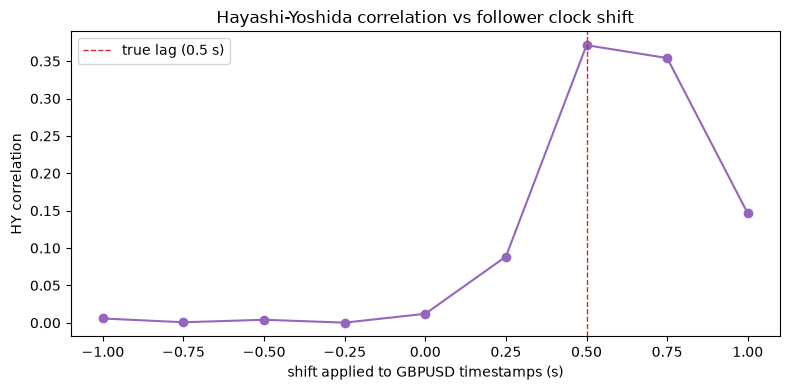

In [7]:
def hy_corr(t_a, r_a, t_b, r_b):
    """Hayashi-Yoshida correlation from interval times and returns."""
    cov = 0.0
    j0 = 0
    for i in range(1, len(t_a)):
        a_lo, a_hi = t_a[i - 1], t_a[i]
        while j0 < len(t_b) - 1 and t_b[j0 + 1] <= a_lo:
            j0 += 1
        j = j0
        while j < len(t_b) - 1 and t_b[j] < a_hi:
            if min(a_hi, t_b[j + 1]) > max(a_lo, t_b[j]):  # overlap
                cov += r_a[i - 1] * r_b[j]
            j += 1
    return cov / np.sqrt((r_a**2).sum() * (r_b**2).sum())

# 2-hour subsample of raw ticks, pulled with a pruned time-range scan
sub = (
    db.table("fx")
    .filter(col("ts") >= "2026-06-01T06:00:00Z", col("ts") < "2026-06-01T08:00:00Z")
    .select("ts", "pair", mid=(col("bid") + col("ask")) / 2)
    .sort("ts")
    .to_pandas()
)
te, tg = {}, {}
for p, g in sub.groupby("pair"):
    ts_us = g["ts"].astype("int64").to_numpy()
    (te if p == "EURUSD" else tg)["t"] = ts_us
    (te if p == "EURUSD" else tg)["r"] = np.diff(np.log(g["mid"].to_numpy()))

shifts_ms = np.arange(-1000, 1001, 250)
hy = [
    hy_corr(te["t"][1:], te["r"], tg["t"][1:] - s * 1000, tg["r"])
    for s in shifts_ms
]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(shifts_ms / 1000, hy, marker="o", color="tab:purple")
ax.axvline(0.5, color="tab:red", ls="--", lw=1, label="true lag (0.5 s)")
ax.set_title("Hayashi-Yoshida correlation vs follower clock shift")
ax.set_xlabel("shift applied to GBPUSD timestamps (s)")
ax.set_ylabel("HY correlation")
ax.legend()
fig.tight_layout()
best = shifts_ms[int(np.argmax(hy))]
print(f"HY peak at shift {best} ms: corr {max(hy):.2f}   (unshifted: {hy[4]:.2f})")

The HY correlogram recovers the injected lag exactly: a sharp peak at +500 ms,
no rightward smear, and a peak correlation at least as high as the best
bucketed estimate, with no grid throwing information away.

The unshifted HY value is near zero for the right reason. Contemporaneously
these series really are nearly unrelated, and the dependence lives entirely at
the half-second offset.

## 5. Reality check: a daily equity pair

The same CCF machinery, now on real KO/PEP daily closes from the cached
30-name S&P sample. Those come from `cu.fetch_daily`, one row per symbol per
session, of which we keep `ts`, `symbol` and `adj_close`.

At daily horizon in liquid large caps, the honest expectation is a strong
contemporaneous correlation and *no* exploitable cross-lag. Information that
took 500 ms in our synthetic market takes well under a day in real ones.

In [8]:
daily = cu.fetch_daily(cu.SP500_EXAMPLES, start="2018-01-01", end="2026-07-01").to_pandas()
pair_df = (
    daily[daily["symbol"].isin(["KO", "PEP"])][["ts", "symbol", "adj_close"]]
    .sort_values(["ts", "symbol"])
    .reset_index(drop=True)
)
eq_schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("adj_close", pa.float64()),
    ]
)
db.create_table("equity_daily", eq_schema, time_column="ts", sort_key=["ts", "symbol"])
db.append("equity_daily", pa.Table.from_pandas(pair_df, preserve_index=False).cast(eq_schema), note="KO/PEP daily")

eq = (
    db.table("equity_daily")
    .select(
        "ts", "symbol",
        ret=col("adj_close")
        / sql_expr("lag(adj_close)").over(partition_by="symbol", order_by="ts") - 1,
    )
    .sort("ts")
    .to_pandas()
)
eq_panel = eq.pivot(index="ts", columns="symbol", values="ret").dropna()
eq_band = 1.96 / np.sqrt(len(eq_panel))
eq_ccf = {k: eq_panel["KO"].corr(eq_panel["PEP"].shift(-k)) for k in range(-5, 6)}
print(f"KO->PEP daily CCF ({len(eq_panel)} days, 95% band ±{eq_band:.3f}):")
for k, v in eq_ccf.items():
    flag = " *" if abs(v) > eq_band and k != 0 else ""
    print(f"  lag {k:+d}d: {v:+.3f}{flag}")

KO->PEP daily CCF (2133 days, 95% band ±0.042):
  lag -5d: +0.088 *
  lag -4d: -0.076 *
  lag -3d: -0.042
  lag -2d: +0.005
  lag -1d: -0.064 *
  lag +0d: +0.709
  lag +1d: -0.106 *
  lag +2d: +0.061 *
  lag +3d: -0.028
  lag +4d: -0.046 *
  lag +5d: +0.045 *


Contemporaneous correlation lands around 0.5 to 0.6, and every cross-lag is at
or inside the noise band. There is no daily lead-lag in KO/PEP, as it should
be.

Real lead-lag alpha lives at the horizons of sections 2 to 4, which is exactly
why tick infrastructure matters, along with estimators that respect
asynchronicity.

## Takeaways

- `time_bucket` accepts sub-second widths such as `'250ms'`, so CCF grids come
  straight out of one GROUP BY. `last_value(... ORDER BY ts)` is the
  per-bucket closing mid.
- `asof_join(..., 'backward', tolerance)` aligns irregular series with an
  explicit staleness budget. Unmatched ticks surface as NULLs you can count,
  which is how a match-rate and tolerance audit falls out for free. One
  current-build caveat: keep both join inputs within one storage batch,
  roughly 8k rows, and assert one output row per left row, because larger
  inputs are silently truncated.
- Bucketing localizes a lag only to grid precision, and dilutes correlation
  through the Epps effect. Hayashi-Yoshida on raw tick intervals, swept over
  clock shifts, recovered both the exact 500 ms lag and the full correlation.
- Injecting the effect, a known lag and a known beta, turns the notebook into
  a calibration exercise. Every estimator is judged against ground truth, and
  the real-data section is honest about finding nothing at daily horizon.

In [9]:
db.close()